## Align UMAPs for the NMP lineages (subsets) for different timepoints
- Last updated: 10/18/2024
- Author: Yang-Joon Kim

### NOTES:
1. Let's start with the ATAC modality to align ("X_lsi")

### Overview:
- Start with the UMAPs from individual timepoints 
- Find the k-nearest neighbors for each cluster in dataset t to dataset (t+1), using "X_lsi" for all timepoints
- Aligned UMAP should reflect the time-dependence of the dataset


### TO-DO:
- clean documentation on what is the required format for the input datasets

In [2]:
import pandas as pd 
import numpy as np 
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy.sparse import csr_matrix
from scipy.io import mmread
import re

from sklearn.neighbors import NearestNeighbors

import umap.aligned_umap
import sklearn.datasets

## Step 1. Subset for the NMP trajectory population (annotation_ML_coarse)

- mesoderm: ["NMPs", "tail_bud", "PSM", "somites","fast_muscle"]
- neuro-ectoderm: ["NMPs", "spinal_cord", "neural_posterior"]

In [3]:
# load the master object
multiome = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_master_filtered.h5ad")
multiome

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [4]:
# import the dim.reductions
integrated_lsi = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_lsi.csv", index_col=0)
integrated_pca = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_pca.csv", index_col=0)


In [5]:
# filter the integrated_lsi (filter out the rows from the "low_quality_cells")
integrated_lsi = integrated_lsi[integrated_lsi.index.isin(multiome.obs_names)]
integrated_lsi.shape

(94562, 50)

In [8]:
metadata = multiome.obs
metadata.annotation_ML_coarse.unique()

['epidermis', 'pronephros', 'hindbrain', 'spinal_cord', 'neural_optic', ..., 'neurons', 'notochord', 'enteric_neurons', 'neural', 'primordial_germ_cells']
Length: 32
Categories (32, object): ['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', ..., 'pronephros', 'somites', 'spinal_cord', 'tail_bud']

In [9]:
# create a dictionary to map the timepoints to each "dataset"
dict_timepoints = {"0somites":"TDR126",
                   "5somites":"TDR127",
                   "10somites":"TDR128",
                   "15somites":"TDR118",
                   "15somites-2":"TDR119",
                   "20somites":"TDR125",
                   "30somites":"TDR124",
}
# Creating a reversed dictionary
reversed_dict_timepoints = {value: key for key, value in dict_timepoints.items()}

print(reversed_dict_timepoints)

{'TDR126': '0somites', 'TDR127': '5somites', 'TDR128': '10somites', 'TDR118': '15somites', 'TDR119': '15somites-2', 'TDR125': '20somites', 'TDR124': '30somites'}


In [10]:
metadata["timepoints"] = metadata.dataset.map(reversed_dict_timepoints)
metadata.head()

,orig_ident,nCount_RNA,nFeature_RNA,nCount_ATAC,nFeature_ATAC,nucleosome_signal,nucleosome_percentile,TSS_enrichment,TSS_percentile,nCount_SCT,...,integrated_weight,peaks_integrated_weight,wsnn_res_0_8,seurat_clusters,data_source,annotation_ML,scANVI_zscape,annotation_ML_coarse,dev_stage,timepoints
AAACAGCCACCTAAGC-1_1,SeuratProject,6522.0,2317,21425.0,9781,0.571984,0.40,4.488213,0.48,5661.0,...,4.062589e-01,0.593741,2,10,multiome,epidermis,contains head vasculature?,epidermis,15somites,15somites
AAACAGCCAGGGAGGA-1_1,SeuratProject,6100.0,2319,10334.0,5028,0.448143,0.13,4.795205,0.75,5553.0,...,7.616462e-01,0.238354,8,16,multiome,pronephros,vascular smooth muscle,pronephros,15somites,15somites
AAACAGCCATAGACCC-1_1,SeuratProject,12581.0,3467,51485.0,19874,0.514213,0.24,5.238692,0.92,5781.0,...,5.938950e-08,1.000000,6,14,multiome,hindbrain,fin bud mesoderm (pectoral),hindbrain,15somites,15somites
AAACATGCAAACTCAT-1_1,SeuratProject,5642.0,2145,19812.0,9183,0.673319,0.85,4.409525,0.41,5363.0,...,3.694048e-01,0.630595,0,0,multiome,spinal_cord,posterior spinal cord progenitors,spinal_cord,15somites,15somites
AAACATGCAAGGACCA-1_1,SeuratProject,2691.0,838,5182.0,2565,0.394904,0.06,4.939061,0.83,4727.0,...,3.265597e-02,0.967344,23,3,multiome,neural_optic2,pharynx,neural_optic,15somites,15somites


In [11]:
# First, subset for the NMP trajectories - celltypes that are in Figure 6, zebrahub
celltypes_NMPs = ["NMPs", "tail_bud", "PSM", "somites", "fast_muscle",
                  "spinal_cord", "neural_posterior"]

# subset the metadata and lsi
metadata_NMPs = metadata[metadata.annotation_ML_coarse.isin(celltypes_NMPs)]
integrated_lsi_NMPs = integrated_lsi[metadata.annotation_ML_coarse.isin(celltypes_NMPs)]

In [12]:
# define the timepointns to subset the metadata and lsi for individual timepoint
timepoints = ['0somites', '5somites', '10somites', '15somites','15somites-2', '20somites', '30somites']

In [13]:
# subset the metadata dataframe
meta_list = []
for timepoint in timepoints:
    df = metadata_NMPs[metadata_NMPs.timepoints==timepoint]
    meta_list.append(df)

In [14]:
metadata_NMPs.timepoints.unique()

['15somites', '15somites-2', '30somites', '20somites', '0somites', '5somites', '10somites']
Categories (7, object): ['15somites', '15somites-2', '30somites', '20somites', '0somites', '5somites', '10somites']

In [15]:
# subset the lsi dataframe
lsi_list = []
lsi_df_list = []
n_lsis = 40

for timepoint in timepoints:
    # subset the metadata first, to use the indices for integrated_lsi subsetting (as they match)
    df_meta = metadata_NMPs[metadata_NMPs.timepoints==timepoint]
    # subset the integrated_lsi using the indices
    df_lsi = integrated_lsi_NMPs[integrated_lsi_NMPs.index.isin(df_meta.index)]
    
    print(df_meta.shape)
    print(df_lsi.shape)
    
    # add the lsi list
    lsi_df_list.append(df_lsi)
    
    # extract the lsi components
    X = df_lsi.values
    # subset for 2:n_lsis components (we exclude the first LSI as it's usually correlated to the seq.depth)
    lsi_list.append(X[:,1:n_lsis])


(4625, 35)
(4625, 50)
(5320, 35)
(5320, 50)
(2637, 35)
(2637, 50)
(3390, 35)
(3390, 50)
(2709, 35)
(2709, 50)
(4319, 35)
(4319, 50)
(1254, 35)
(1254, 50)


Based on the distribution of distances we can select the top % of cells to use as anchors between the two datasets. 

In [29]:
for m in meta_list:
    print(m.shape)

(4625, 35)
(5320, 35)
(2637, 35)
(3390, 35)
(2709, 35)
(4319, 35)
(1254, 35)


In [30]:
for lsi in lsi_list: 
    print(lsi.shape)

(4625, 39)
(5320, 39)
(2637, 39)
(3390, 39)
(2709, 39)
(4319, 39)
(1254, 39)


Merge PCA projections

### Run Aligned UMAP

Create list of dictionaries 

In [31]:
anchor_dict = []
# # Parameter set 1: 
# max_k = 10
# frac_k = 0.05
# max_dist = 0.05
# use_metric = 'cosine'

# Parameter set 2: 
max_k = 20
frac_k = 0.05
max_dist = 0.05
use_metric = 'cosine'

annotation_class = "annotation_ML_coarse"

for i in range(len(timepoints)-1):
    Y = lsi_list[i] # train on previous timepoint "progenitor space"
    X = lsi_list[i+1] # for cells in next timepoint predict "progenitors"
    
    nbrs = NearestNeighbors(n_neighbors=1, #algorithm='ball_tree',
                           metric = use_metric).fit(Y)
    
    distances, indices = nbrs.kneighbors(X) # predict top progenitor for all cells
    
    neigh_distribution = np.concatenate(distances, axis = 0)
    neigh_indexes = np.concatenate(indices, axis =0)
    
    pairs = pd.DataFrame( {'neighbor':neigh_indexes ,'dist':neigh_distribution})
    pairs.reset_index(inplace = True)
    pairs.rename(columns ={'index':'cell_target'},inplace=True)
    
    # Grup by cell type (we'll find top anchors for each cell type)
    pairs['cell_type'] = meta_list[i+1][annotation_class].values
    df1 = pairs.groupby(['cell_type'])

    df2 = df1.apply(lambda x: x.sort_values(["dist"]))

    df3=df2.reset_index(drop=True)

    # keep the top neighbors for each cell type (NOTE some cells in t+1 will map to many cells in t)
    
    # For each progenitor in t keep only the cell in (t+1) with the smallest distance
    # Closest relative
    pairs_rank = df3.groupby('neighbor').head(1)
    
    #pairs_rank = df3.groupby('cell_type').head(max_k)
    
    # For each cell type we keep the top k prgenitor relations 
    pairs_rank = pairs_rank.groupby('cell_type').head(max_k)
    
    # filter any neighbor pair with distance larger than threshold
    pairs_rank = pairs_rank[pairs_rank['dist']<max_dist] 
    
    
    pairs_dict = {pairs_rank['neighbor'].values[j] :pairs_rank['cell_target'].values[j]  for j in range(pairs_rank.shape[0])}
    
    
    anchor_dict.append(pairs_dict)

/tmp/ipykernel_889537/1417113939.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1 = pairs.groupby(['cell_type'])
/tmp/ipykernel_889537/1417113939.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df1.apply(lambda x: x.sort_values(["dist"]))
/tmp/ipykernel_889537/1417113939.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and s

In [33]:
aligned_mapper = umap.AlignedUMAP(metric="cosine",
                                    n_neighbors=20,
                                    alignment_regularisation=0.01, # strength of the anchors across timepoints, default 0.1
                                    alignment_window_size=3, # how far forward and backward across the datasets we look when doing alignment, defaut 5
                                    n_epochs=200,
                                    random_state=42,).fit(lsi_list, relations=anchor_dict)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [34]:
all_timepoints = []
annotation_class = "annotation_ML_coarse"
for i in range(0,len(timepoints)):
    aligned_umap_coord = pd.DataFrame( {'UMAP_1':aligned_mapper.embeddings_[i].T[0], 'UMAP_2':aligned_mapper.embeddings_[i].T[1], 
                                        'timepoint' :timepoints[i], 
                                        'cell_type':meta_list[i][annotation_class].values, 
                                        'cell_id' : meta_list[i].index.to_list()})
    all_timepoints.append(aligned_umap_coord)
    
umap_coords = pd.concat(all_timepoints)

In [35]:
import os

In [36]:
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/aligned_umaps_NMPs_v2/"
os.makedirs(figpath, exist_ok=True)

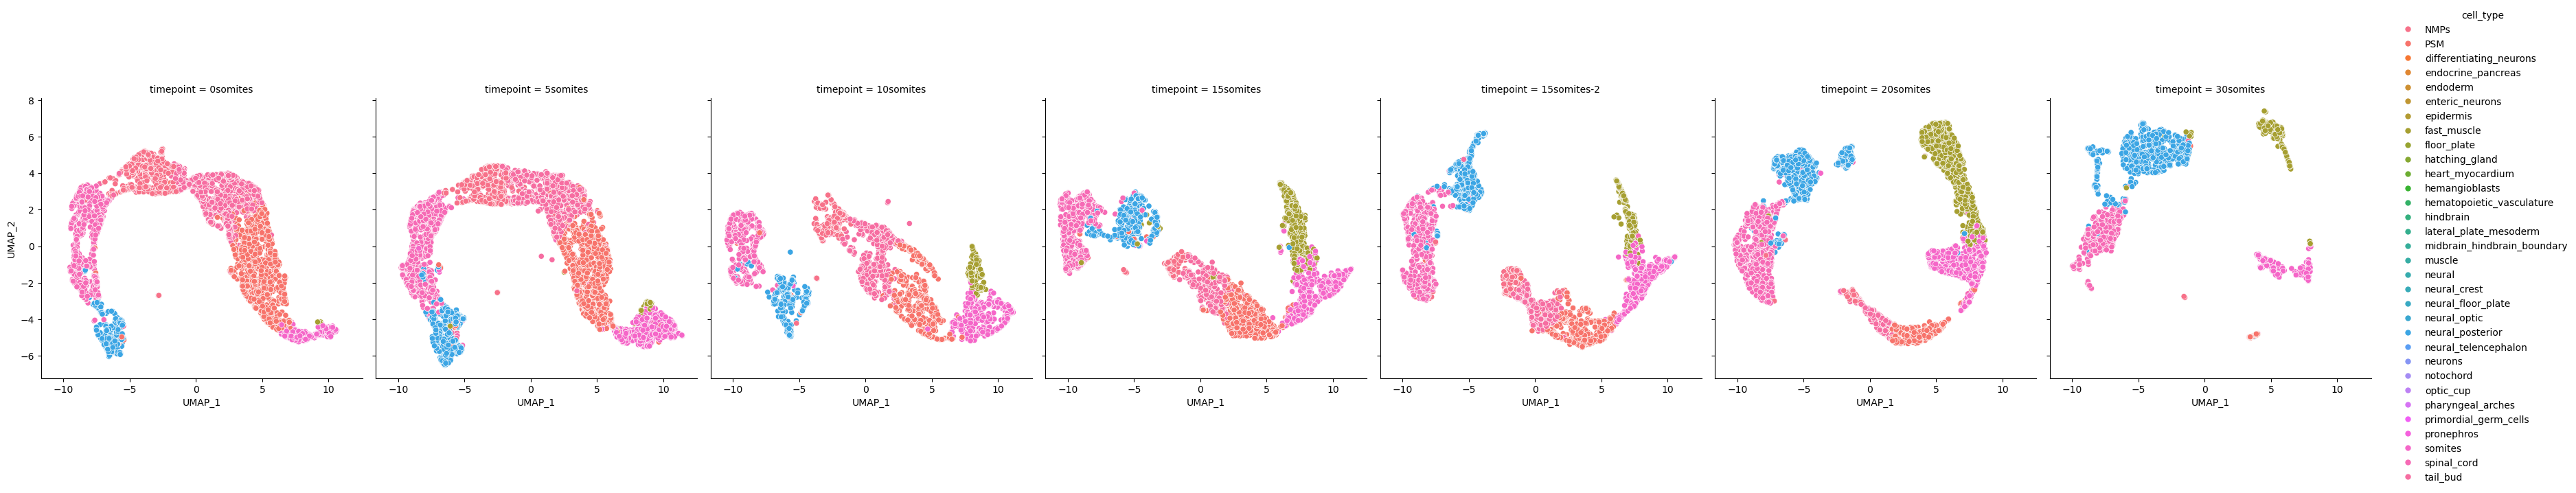

In [37]:
sns.relplot(
    data=umap_coords, x="UMAP_1", y="UMAP_2",
    col="timepoint", hue="cell_type",
    kind="scatter"
)

# plt.savefig(figpath + "aligned_umap_NMPs_timepoints.png")
# plt.savefig(figpath + "aligned_umap_NMPs_timepoints.pdf")

### try with different hyper-parameters


In [16]:
anchor_dict = []
# # Parameter set 1: 
# max_k = 10
# frac_k = 0.05
# max_dist = 0.05
# use_metric = 'cosine'

# Parameter set 2: 
max_k = 20
frac_k = 0.05
max_dist = 0.05
use_metric = 'cosine'

annotation_class = "annotation_ML_coarse"

for i in range(len(timepoints)-1):
    Y = lsi_list[i] # train on previous timepoint "progenitor space"
    X = lsi_list[i+1] # for cells in next timepoint predict "progenitors"
    
    nbrs = NearestNeighbors(n_neighbors=1, #algorithm='ball_tree',
                           metric = use_metric).fit(Y)
    
    distances, indices = nbrs.kneighbors(X) # predict top progenitor for all cells
    
    neigh_distribution = np.concatenate(distances, axis = 0)
    neigh_indexes = np.concatenate(indices, axis =0)
    
    pairs = pd.DataFrame( {'neighbor':neigh_indexes ,'dist':neigh_distribution})
    pairs.reset_index(inplace = True)
    pairs.rename(columns ={'index':'cell_target'},inplace=True)
    
    # Grup by cell type (we'll find top anchors for each cell type)
    pairs['cell_type'] = meta_list[i+1][annotation_class].values
    df1 = pairs.groupby(['cell_type'])

    df2 = df1.apply(lambda x: x.sort_values(["dist"]))

    df3=df2.reset_index(drop=True)

    # keep the top neighbors for each cell type (NOTE some cells in t+1 will map to many cells in t)
    
    # For each progenitor in t keep only the cell in (t+1) with the smallest distance
    # Closest relative
    pairs_rank = df3.groupby('neighbor').head(1)
    
    #pairs_rank = df3.groupby('cell_type').head(max_k)
    
    # For each cell type we keep the top k prgenitor relations 
    pairs_rank = pairs_rank.groupby('cell_type').head(max_k)
    
    # filter any neighbor pair with distance larger than threshold
    pairs_rank = pairs_rank[pairs_rank['dist']<max_dist] 
    
    
    pairs_dict = {pairs_rank['neighbor'].values[j] :pairs_rank['cell_target'].values[j]  for j in range(pairs_rank.shape[0])}
    
    
    anchor_dict.append(pairs_dict)

/tmp/ipykernel_2154440/1417113939.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1 = pairs.groupby(['cell_type'])
/tmp/ipykernel_2154440/1417113939.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df1.apply(lambda x: x.sort_values(["dist"]))
/tmp/ipykernel_2154440/1417113939.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default an

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


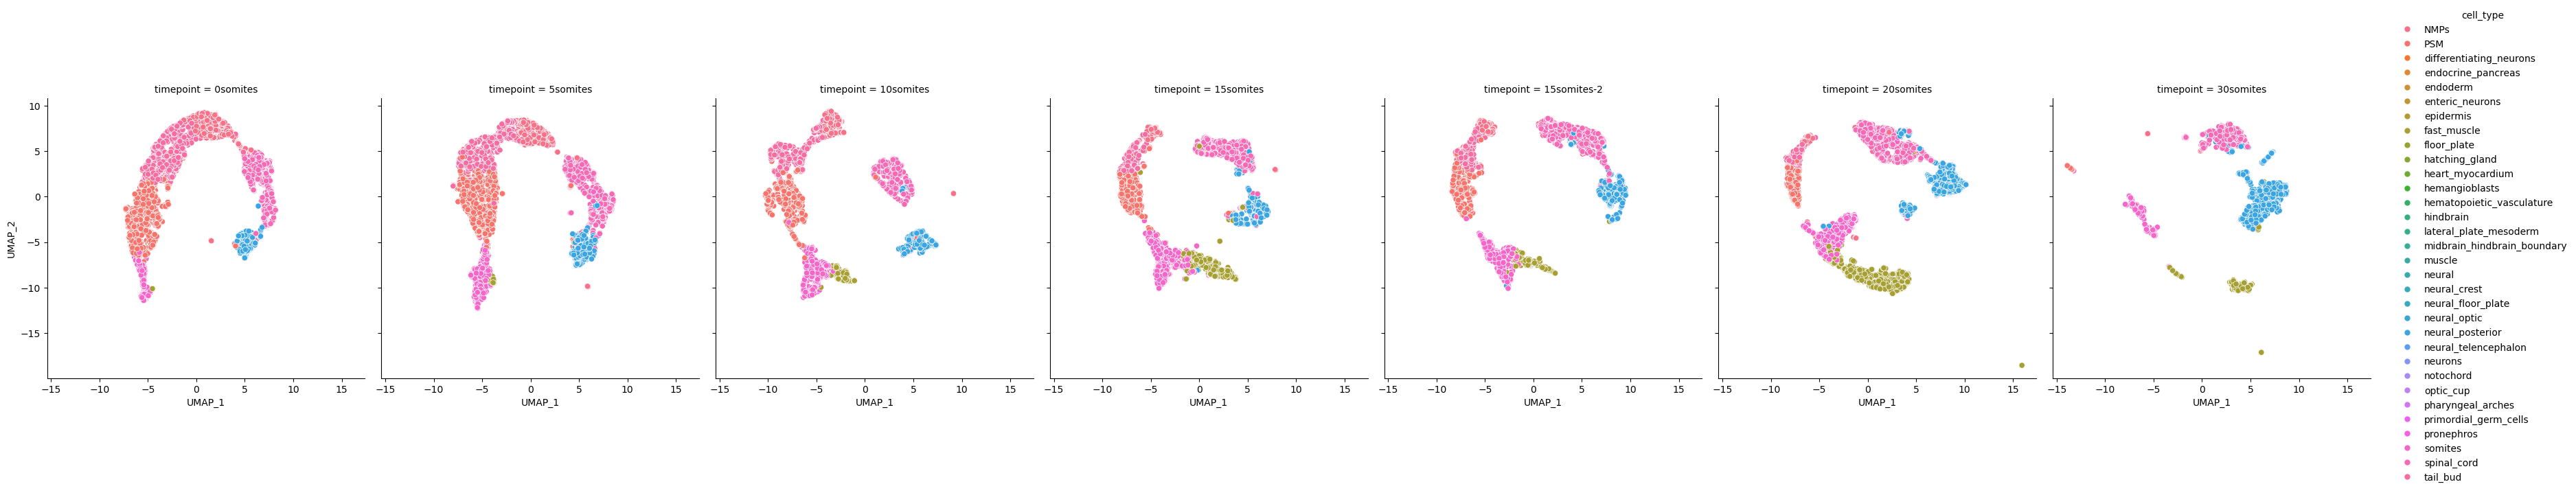

In [17]:
aligned_mapper = umap.AlignedUMAP(metric="cosine",
                                    n_neighbors=10,
                                    alignment_regularisation=0.001, # strength of the anchors across timepoints, default 0.1
                                    alignment_window_size=7, # how far forward and backward across the datasets we look when doing alignment, defaut 5
                                    n_epochs=200,
                                    random_state=42,).fit(lsi_list, relations=anchor_dict)

all_timepoints = []
annotation_class = "annotation_ML_coarse"
for i in range(0,len(timepoints)):
    aligned_umap_coord = pd.DataFrame( {'UMAP_1':aligned_mapper.embeddings_[i].T[0], 'UMAP_2':aligned_mapper.embeddings_[i].T[1], 
                                        'timepoint' :timepoints[i], 
                                        'cell_type':meta_list[i][annotation_class].values, 
                                        'cell_id' : meta_list[i].index.to_list()})
    all_timepoints.append(aligned_umap_coord)
    
umap_coords = pd.concat(all_timepoints)

sns.relplot(
    data=umap_coords, x="UMAP_1", y="UMAP_2",
    col="timepoint", hue="cell_type",
    kind="scatter"
)

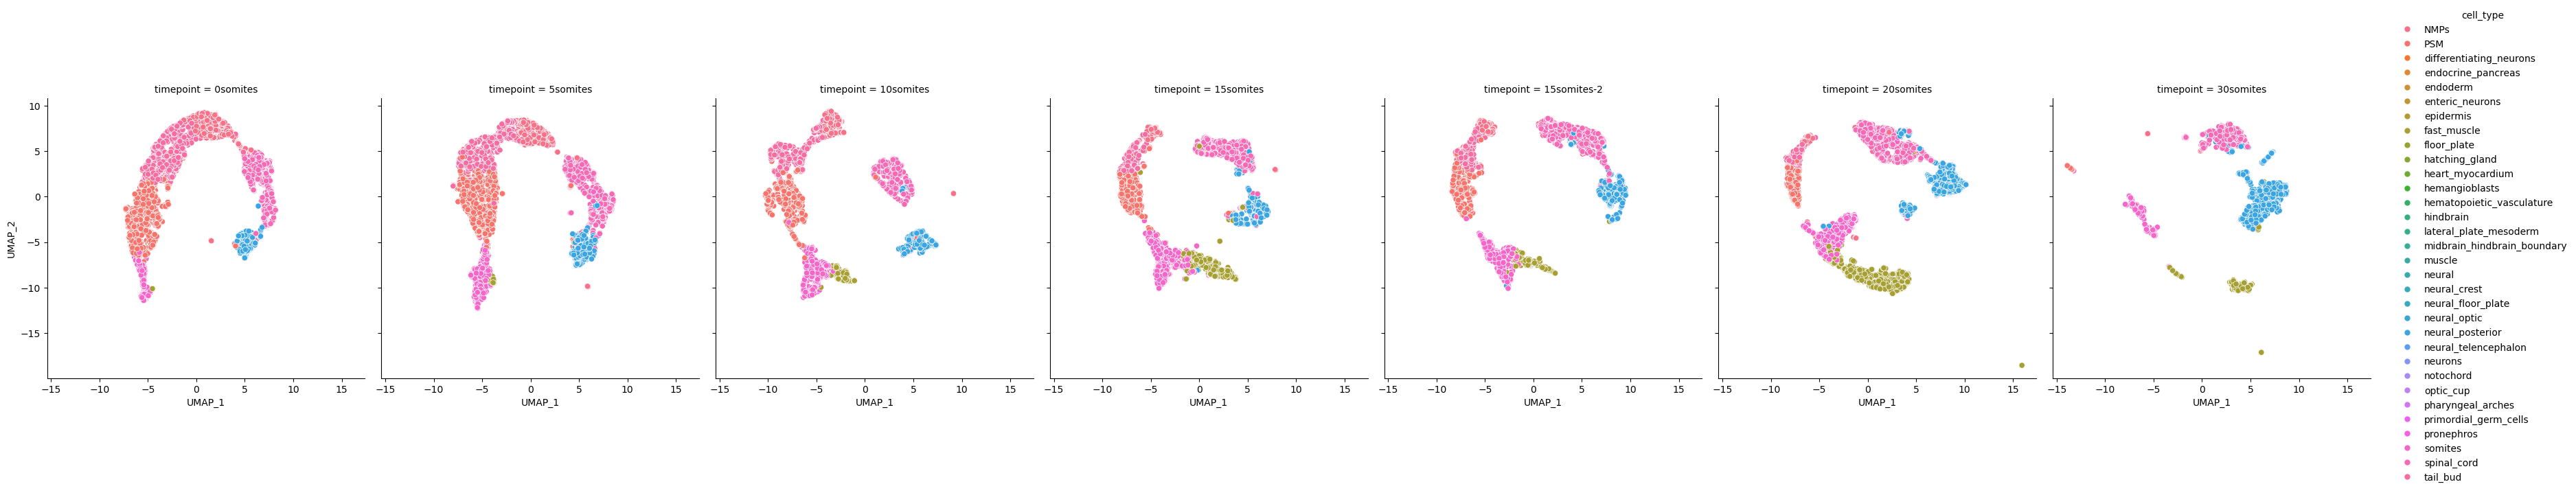

In [54]:
aligned_mapper = umap.AlignedUMAP(metric="cosine",
                                    n_neighbors=10,
                                    alignment_regularisation=0.001, # strength of the anchors across timepoints, default 0.1
                                    alignment_window_size=7, # how far forward and backward across the datasets we look when doing alignment, defaut 5
                                    n_epochs=200,
                                    random_state=42,).fit(lsi_list, relations=anchor_dict)

all_timepoints = []
annotation_class = "annotation_ML_coarse"
for i in range(0,len(timepoints)):
    aligned_umap_coord = pd.DataFrame( {'UMAP_1':aligned_mapper.embeddings_[i].T[0], 'UMAP_2':aligned_mapper.embeddings_[i].T[1], 
                                        'timepoint' :timepoints[i], 
                                        'cell_type':meta_list[i][annotation_class].values, 
                                        'cell_id' : meta_list[i].index.to_list()})
    all_timepoints.append(aligned_umap_coord)
    
umap_coords = pd.concat(all_timepoints)

sns.relplot(
    data=umap_coords, x="UMAP_1", y="UMAP_2",
    col="timepoint", hue="cell_type",
    kind="scatter"
)

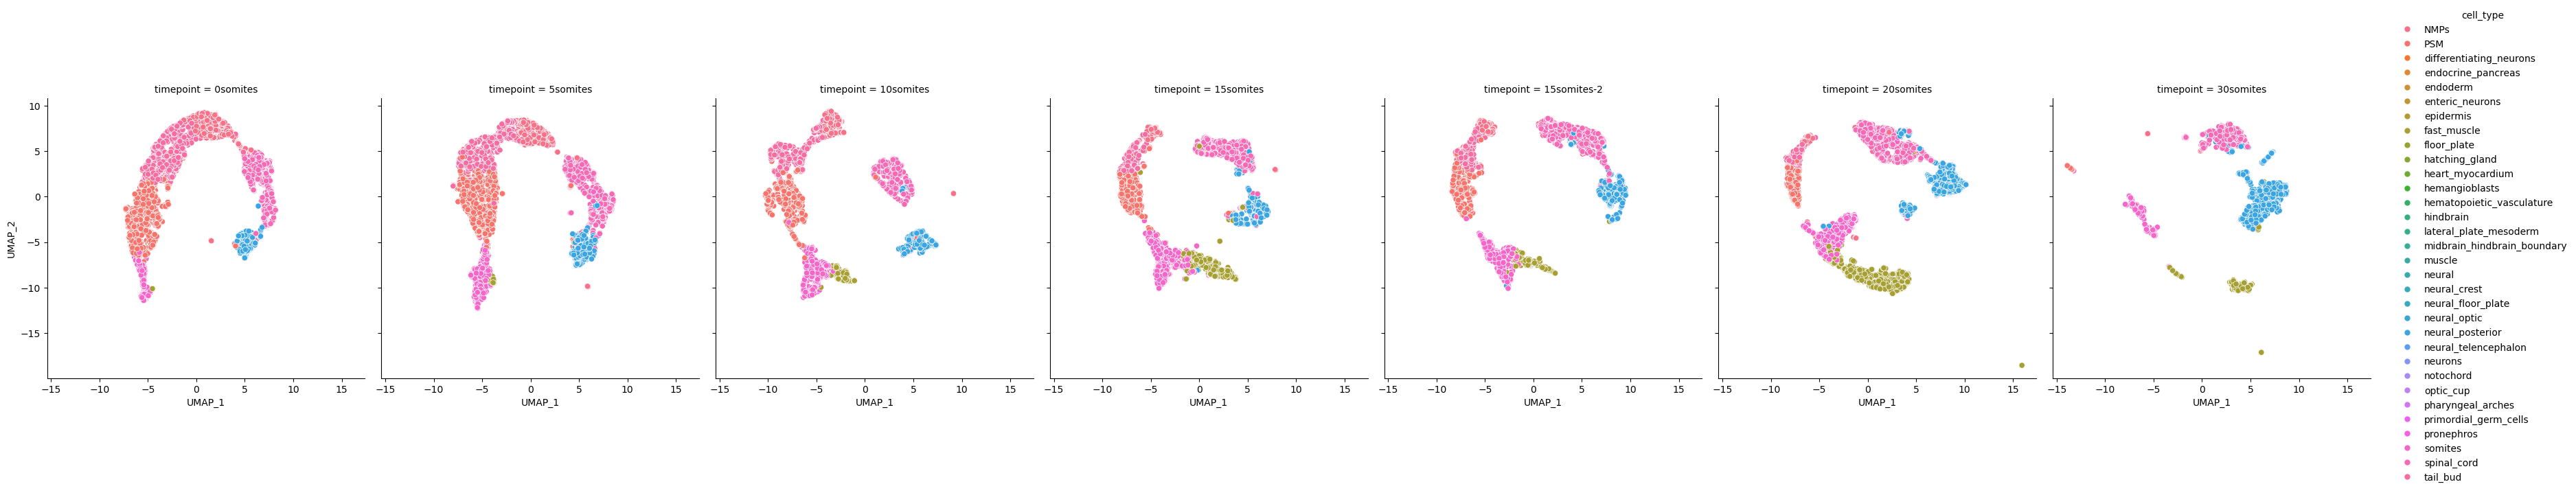

In [56]:
sns.relplot(
    data=umap_coords, x="UMAP_1", y="UMAP_2",
    col="timepoint", hue="cell_type",
    kind="scatter"
)

plt.savefig(figpath + "aligned_umap_NMPs_timepoints.png")
plt.savefig(figpath + "aligned_umap_NMPs_timepoints.pdf")

### These UMAPs do look better! Now, let's see how many NMP cells are there at each timepoint


In [58]:
# save the aligned_umap coordinates for all timepoints (note that TDR119reseq was excluded)
umap_coords.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/aligned_umap_coords_NMPs_v2.csv")

In [79]:
aligned_umap_coord.loc[:,["UMAP_1","UMAP_2"]].values

array([[-7.0254636 , -1.2118834 ],
       [ 6.792777  ,  0.566063  ],
       [ 7.4695935 ,  0.34464994],
       ...,
       [ 4.249009  ,  2.4352841 ],
       [-3.0290074 , -8.121992  ],
       [ 1.8300722 ,  7.2341113 ]], dtype=float32)

## Subsetting the alignedUMAP coordinates to each timepoint adata

In [59]:
aligned_umap_coords = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/aligned_umap_coords_NMPs_v2.csv", index_col=0)
aligned_umap_coords

,UMAP_1,UMAP_2,timepoint,cell_type,cell_id
0,5.142314,3.952904,0somites,spinal_cord,AAACAGCCAACACTTG-1_5
1,-5.316204,-5.724757,0somites,PSM,AAACAGCCACAATGCC-1_5
2,4.533801,-4.184461,0somites,neural_posterior,AAACAGCCACCTGGTG-1_5
3,1.386830,6.767145,0somites,NMPs,AAACAGCCAGTTATCG-1_5
4,-3.521732,1.727359,0somites,PSM,AAACATGCAAACTGCC-1_5
...,...,...,...,...,...
1249,2.643997,7.275272,30somites,spinal_cord,TTTGCGACACCAAAGG-1_3
1250,2.988940,7.375273,30somites,spinal_cord,TTTGTCCCATTAGGTT-1_3
1251,4.249009,2.435284,30somites,neural_posterior,TTTGTCCCATTGTCCT-1_3
1252,-3.029007,-8.121992,30somites,fast_muscle,TTTGTGGCATAGCGGA-1_3


In [69]:
reversed_dict_timepoints

{'TDR126': '0somites',
 'TDR127': '5somites',
 'TDR128': '10somites',
 'TDR118': '15somites',
 'TDR119': '15somites-2',
 'TDR125': '20somites',
 'TDR124': '30somites'}

In [70]:
reversed_dict_timepoints["TDR126"]

'0somites'

In [67]:
aligned_umap_coords.timepoint.unique()

array(['0somites', '5somites', '10somites', '15somites', '15somites-2',
       '20somites', '30somites'], dtype=object)

In [6]:
# # import the h5ad object for all cells across all timepoints
# multiome = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA.h5ad")
# multiome

/hpc/user_apps/data.science/conda_envs/single-cell-basics/lib/python3.8/site-packages/anndata/compat/__init__.py:232: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 4117 × 2000
    obs: 'seurat_clusters_res1.5', 'seqrun', 'leiden_v6_r0.32', 'leiden_v5_r0.35', 'annotation_seuratres1_5_v3', 'integrated_snn_res.0.5', 'orig.ident', 'fish_n', 'global_annotation', 'leiden_v11_r0.22', 'leiden_v4_r0.3', 'leiden_v3_r0.2', 'leiden_v10_r0.25', 'cell_annotation', 'fish', 'seurat_clusters', 'leiden_v2_r0.5', 'leiden_v12_r0.23', 'annotation_umapv2', 'annotation_umapv2_recluster', 'timepoint', 'leiden_v1_r1', 'leiden_v8_r0.31', 'X10X_run', 'annotation_umapv2_global', 'leiden_v9_r0.31', 'leiden_v7_r0.3', 'nCount_RNA', 'nFeature_RNA'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

In [61]:
# First, subset the dataset into multiome 
multiome_NMPs = multiome[multiome.obs_names.isin(aligned_umap_coords.cell_id)]
multiome_NMPs

View of AnnData object with n_obs × n_vars = 24254 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage', 'timepoints'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [81]:
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/aligned_umaps_NMPs_v2/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

/tmp/ipykernel_889537/2286539887.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tool

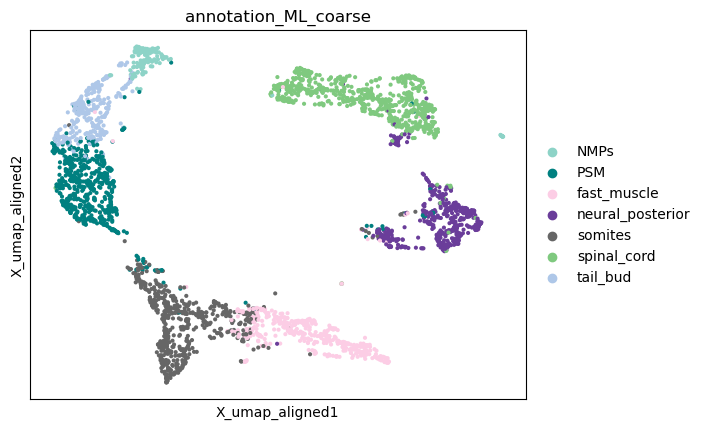

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

/tmp/ipykernel_889537/2286539887.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tool

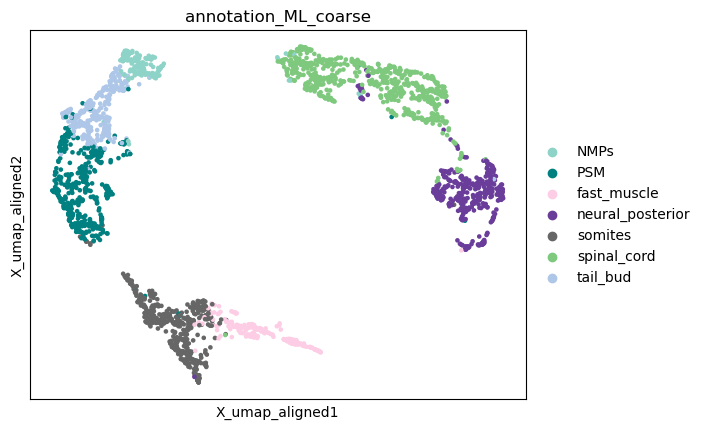

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

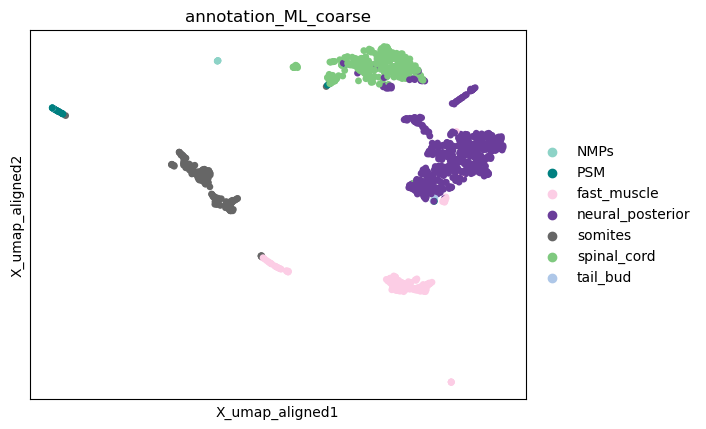

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

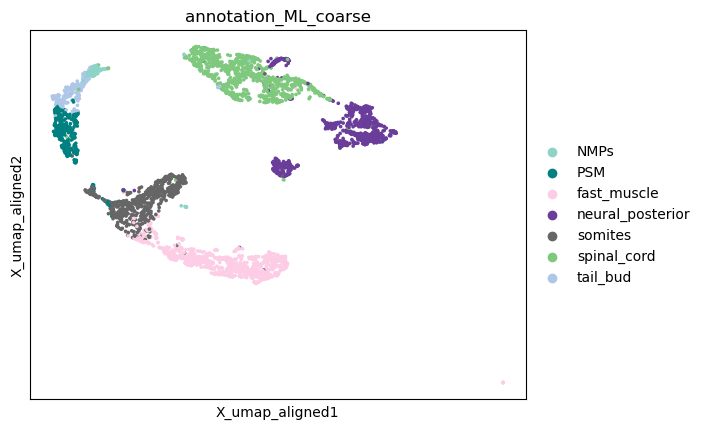

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

/tmp/ipykernel_889537/2286539887.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tool

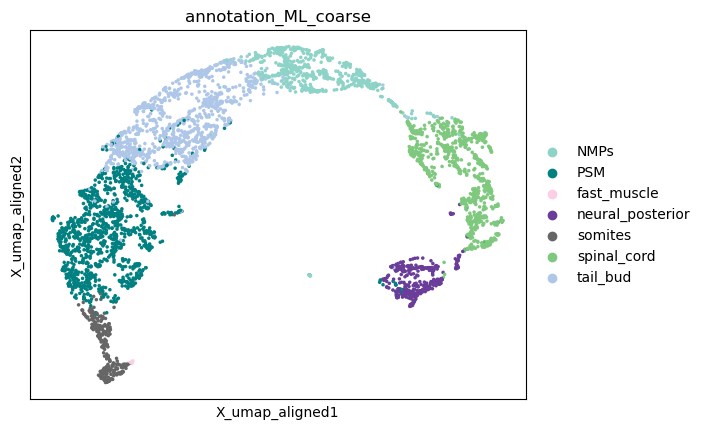

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

/tmp/ipykernel_889537/2286539887.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tool

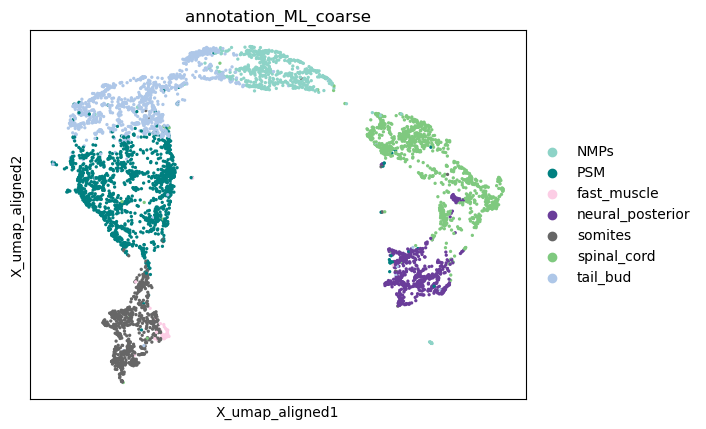

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

/tmp/ipykernel_889537/2286539887.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tool

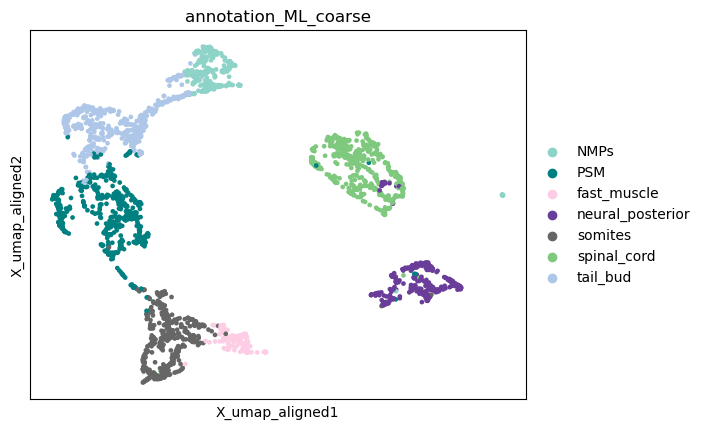

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

In [82]:
multiome_NMPs.obs.dataset.unique()

for dataset in multiome_NMPs.obs.dataset.unique():
    # subset the multiome adata object for each dataset
    adata_sub = multiome_NMPs[multiome_NMPs.obs.dataset==dataset]
    
    # check which timepoint does the dataset correspond to
    timepoint_id = reversed_dict_timepoints[dataset]
    
    # subset the umap_coords
    umap_coords_sub = aligned_umap_coords[aligned_umap_coords.timepoint==timepoint_id]
    
    # transfer the umap_coords to the adata_sub.obsm
    adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values
    
    # sc.pl.embedding(adata_sub, basis="X_umap_aligned", color="annotation_ML_coarse", save=f"_{dataset}_aligned_umap.pdf")
    # sc.pl.embedding(adata_sub, basis="X_umap_aligned", color="annotation_ML_coarse", save=f"_{dataset}_aligned_umap.png", show=False)

In [83]:
multiome_NMPs.obs.dataset.unique()

for dataset in multiome_NMPs.obs.dataset.unique():
    # subset the multiome adata object for each dataset
    adata_sub = multiome_NMPs[multiome_NMPs.obs.dataset==dataset]
    
    # check which timepoint does the dataset correspond to
    timepoint_id = reversed_dict_timepoints[dataset]
    
    # subset the umap_coords
    umap_coords_sub = aligned_umap_coords[aligned_umap_coords.timepoint==timepoint_id]
    
    # transfer the umap_coords to the adata_sub.obsm
    adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values
    
    adata_sub.write_h5ad(f"/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/09_NMPs_subsetted_v2/{dataset}_NMPs.h5ad")
    print(dataset)

/tmp/ipykernel_889537/1657759718.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values


TDR118


/tmp/ipykernel_889537/1657759718.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values


TDR119
TDR124


/tmp/ipykernel_889537/1657759718.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values
/tmp/ipykernel_889537/1657759718.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values


...

TDR126


/tmp/ipykernel_889537/1657759718.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values


TDR127


/tmp/ipykernel_889537/1657759718.py:14: ImplicitModificationWarning: Setting element `.obsm['X_umap_aligned']` of view, initializing view as actual.
  adata_sub.obsm["X_umap_aligned"] = umap_coords_sub.loc[:,["UMAP_1","UMAP_2"]].values


TDR128


## After manual curation of celltype annotation - based on individual UMAPs and integrated UMAPs

- 1) curated "notochord" cells mis-labelled as "NMPs". Typically, these were isolated and further apart from the rest of the NMP clusters.

- 2) identified "low_quality" cells that seem to be further apart from the main NMP cluster in the "integrated" UMAP. These are likely very vague celltypes and potentially confuse the pseudotime computation.

In [91]:
adata_sub.shape[0]

2637

In [98]:
# step 1. for each "data_id", 1) import the subsetted adata (v1), 
# and 2) the curated annotation(df).
# step 2. transfer the annotations from the "manual_annotation" dataframe
# step 3. filter out "notochord" and "low_quality" cells
# step 4. save the objects with curated annotation ("manual_annotation")

celltypes_NMPs = ["NMPs", "tail_bud", "PSM", "somites", "fast_muscle",
                  "spinal_cord", "neural_posterior"]

# define the filepaths
adata_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/09_NMPs_subsetted_v2/subsetted_from_integrated_object/"
annotation_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/09_NMPs_subsetted_v2/manual_annotation_exCellxgene/"
output_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/09_NMPs_subsetted_v2/"

for data_id in reversed_dict_timepoints.keys():
    # import the adata (subsetted)
    subset = sc.read_h5ad(adata_path + f"{data_id}_NMPs.h5ad")
    print("n_cells: ", str(subset.shape[0]))
    # import the manual annotation df
    df_anno = pd.read_csv(annotation_path + f"{data_id}_nmps_manual_annotation.txt", sep="\t", index_col=0)
    
    # transfer the manual_annotation
    subset.obs["manual_annotation"] = df_anno["manual_annotation"]
    
    # filter out the "notochord", and "low_quality" cells
    subset_filtered = subset[subset.obs.manual_annotation.isin(celltypes_NMPs)]
    print(subset_filtered)
    print("n_cells: ", str(subset_filtered.shape[0]))
    
    # add the "raw counts" back to the adata.X layer for GRN computation
    subset_filtered.X = subset_filtered.layers["counts"].copy()
    # save the output adata
    subset_filtered.write_h5ad(output_path + f"{data_id}_nmps_manual_annotation.h5ad")
    print(f"{data_id} is saved")


n_cells:  4625
View of AnnData object with n_obs × n_vars = 4602 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage', 'timepoints', 'manual_annotation'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_umap

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


TDR126 is saved
n_cells:  5320
View of AnnData object with n_obs × n_vars = 5304 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage', 'timepoints', 'manual_annotation'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_um

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


TDR127 is saved
n_cells:  2637
View of AnnData object with n_obs × n_vars = 2627 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage', 'timepoints', 'manual_annotation'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_um

...

TDR119 is saved
n_cells:  4319
View of AnnData object with n_obs × n_vars = 4283 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage', 'timepoints', 'manual_annotation'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_um

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


TDR125 is saved
n_cells:  1254
View of AnnData object with n_obs × n_vars = 1244 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage', 'timepoints', 'manual_annotation'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_um

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


TDR124 is saved


### generate slurm commands for computing GRNs

In [94]:
# dictionary for data_id and timepoints
dict_datasets = {"0somites":"TDR126",
                 "5somites":"TDR127",
                 "10somites":"TDR128",
                 "15somites":"TDR118reseq",
                 "15somites-2":"TDR119reseq",
                 "20somites":"TDR125reseq",
                 "30somites":"TDR124reseq"}
# List of identifiers for your jobs
identifiers = dict_datasets.values()  # Add more identifiers as needed
# Base paths (assuming these don't change, else they can be added to the loop)
base_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/"
# Template for the command
command_template = """
sbatch compute_co_celltype_GRNs.sh \\
    {base_path}/09_NMPs_subsetted_v2/{sample_id}/ \\
    {base_path}/09_NMPs_subsetted_v2/{sample_id}_nmps_manual_annotation.h5ad \\
    {base_path}/02_cicero_processed/{data_id}_cicero/05_{data_id}_base_GRN_dataframe.parquet \\
    {sample_id} manual_annotation X_umap_aligned
"""
# Generate and print each command
for identifier in identifiers:
    command = command_template.format(base_path=base_path, 
                                      data_id=identifier,
                                      sample_id = identifier.replace("reseq",""))
    print(command)


sbatch compute_co_celltype_GRNs.sh \
    /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data//09_NMPs_subsetted_v2/TDR126/ \
    /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data//09_NMPs_subsetted_v2/TDR126_nmps_manual_annotation.h5ad \
    /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data//02_cicero_processed/TDR126_cicero/05_TDR126_base_GRN_dataframe.parquet \
    TDR126 manual_annotation X_umap_aligned


sbatch compute_co_celltype_GRNs.sh \
    /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data//09_NMPs_subsetted_v2/TDR127/ \
    /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data//09_NMPs_subsetted_v2/TDR127_nmps_manual_annotation.h5ad \
    /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data//02_cicero_processed/TDR127_cicero/05_TDR127_base_GRN_dataframe.parquet \
    TDR127 manual_annotation X_umap_aligned


sbatch comp

In [74]:
timepoints

['0somites', '5somites', '10somites', '15somites', '20somites', '30somites']

In [117]:
metadata_NMPs.timepoints.unique()

array(['15somites', '15somites-2', '30somites', '20somites', '0somites',
       '5somites', '10somites'], dtype=object)

In [118]:
# subset the lsi dataframe
lsi_list = []
lsi_df_list = []
n_lsis = 40

for timepoint in timepoints:
    # subset the metadata first, to use the indices for integrated_lsi subsetting (as they match)
    df_meta = metadata_NMPs[metadata_NMPs.timepoints==timepoint]
    # subset the integrated_lsi using the indices
    df_lsi = integrated_lsi_NMPs[integrated_lsi_NMPs.index.isin(df_meta.index)]
    
    # add the lsi list
    lsi_df_list.append(df_lsi)
    
    # extract the lsi components
    X = df_lsi.values
    # subset for 2:n_lsis components (we exclude the first LSI as it's usually correlated to the seq.depth)
    lsi_list.append(X[:,1:n_lsis])


Based on the distribution of distances we can select the top % of cells to use as anchors between the two datasets. 

In [119]:
for m in meta_list:
    print(m.shape)

(9157, 32)
(11271, 32)
(5800, 32)
(8237, 32)
(11824, 32)
(5002, 32)


In [120]:
for lsi in lsi_list: 
    print(lsi.shape)

(9157, 39)
(11271, 39)
(5800, 39)
(8237, 39)
(11824, 39)
(5002, 39)


Merge PCA projections

### Run Aligned UMAP

Create list of dictionaries 

In [124]:
anchor_dict = []
# # Parameter set 1: 
# max_k = 10
# frac_k = 0.05
# max_dist = 0.05
# use_metric = 'cosine'

# Parameter set 2: 
max_k = 20
frac_k = 0.05
max_dist = 0.05
use_metric = 'cosine'


for i in range(len(timepoints)-1):
    Y = lsi_list[i] # train on previous timepoint "progenitor space"
    X = lsi_list[i+1] # for cells in next timepoint predict "progenitors"
    
    nbrs = NearestNeighbors(n_neighbors=1, #algorithm='ball_tree',
                           metric = use_metric).fit(Y)
    
    distances, indices = nbrs.kneighbors(X) # predict top progenitor for all cells
    
    neigh_distribution = np.concatenate(distances, axis = 0)
    neigh_indexes = np.concatenate(indices, axis =0)
    
    pairs = pd.DataFrame( {'neighbor':neigh_indexes ,'dist':neigh_distribution})
    pairs.reset_index(inplace = True)
    pairs.rename(columns ={'index':'cell_target'},inplace=True)
    
    # Grup by cell type (we'll find top anchors for each cell type)
    pairs['cell_type'] = meta_list[i+1].manual_annotation.values
    df1 = pairs.groupby(['cell_type'])

    df2 = df1.apply(lambda x: x.sort_values(["dist"]))

    df3=df2.reset_index(drop=True)

    # keep the top neighbors for each cell type (NOTE some cells in t+1 will map to many cells in t)
    
    # For each progenitor in t keep only the cell in (t+1) with the smallest distance
    # Closest relative
    pairs_rank = df3.groupby('neighbor').head(1)
    
    #pairs_rank = df3.groupby('cell_type').head(max_k)
    
    # For each cell type we keep the top k prgenitor relations 
    pairs_rank = pairs_rank.groupby('cell_type').head(max_k)
    
    # filter any neighbor pair with distance larger than threshold
    pairs_rank = pairs_rank[pairs_rank['dist']<max_dist] 
    
    
    pairs_dict = {pairs_rank['neighbor'].values[j] :pairs_rank['cell_target'].values[j]  for j in range(pairs_rank.shape[0])}
    
    
    anchor_dict.append(pairs_dict)

/tmp/ipykernel_1826275/946888747.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df1.apply(lambda x: x.sort_values(["dist"]))
/tmp/ipykernel_1826275/946888747.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df1.apply(lambda x: x.sort_values(["dist"]))
/tmp/ipykernel_1826275/946888747.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is de

In [125]:
len(pairs_dict)

88

In [126]:
aligned_mapper = umap.AlignedUMAP(metric="cosine",
                                    n_neighbors=20,
                                    alignment_regularisation=0.1, # strength of the anchors across timepoints, default 0.1
                                    alignment_window_size=3, # how far forward and backward across the datasets we look when doing alignment, defaut 5
                                    n_epochs=200,
                                    random_state=42,).fit(lsi_list, relations=anchor_dict)

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/pyth

In [127]:
all_timepoints = []
for i in range(0,len(timepoints)):
    aligned_umap_coord = pd.DataFrame( {'UMAP_1':aligned_mapper.embeddings_[i].T[0], 'UMAP_2':aligned_mapper.embeddings_[i].T[1], 
                                        'timepoint' :timepoints[i], 
                                        'cell_type':meta_list[i]["manual_annotation"].values, 
                                        'cell_id' : meta_list[i].index.to_list()})
    all_timepoints.append(aligned_umap_coord)
    
umap_coords = pd.concat(all_timepoints)

In [144]:
import os

In [145]:
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/aligned_umaps/"
os.makedirs(figpath, exist_ok=True)

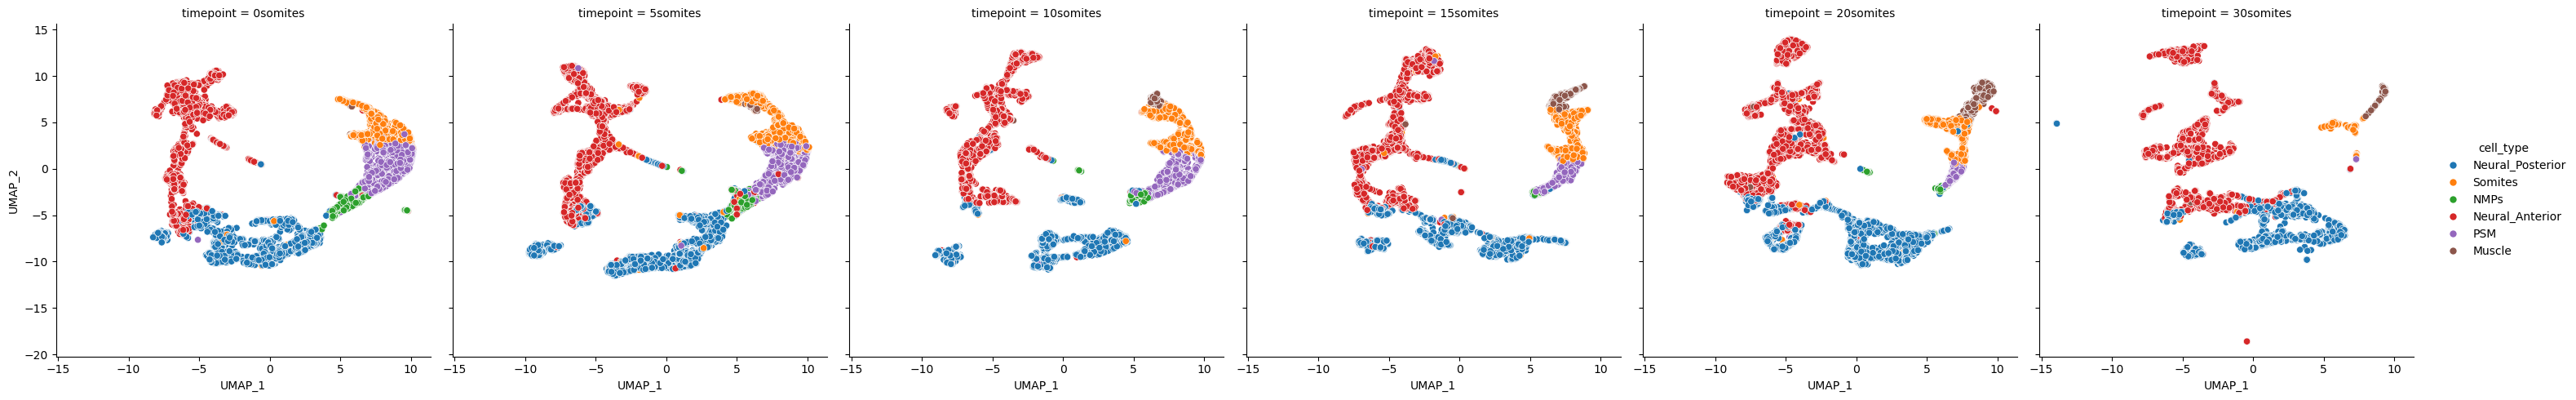

In [146]:
sns.relplot(
    data=umap_coords, x="UMAP_1", y="UMAP_2",
    col="timepoint", hue="cell_type",
    kind="scatter"
)

plt.savefig(figpath + "aligned_umap_NMPs_timepoints.png")
plt.savefig(figpath + "aligned_umap_NMPs_timepoints.pdf")

Load meta data

### These UMAPs do look better! Now, let's see how many NMP cells are there at each timepoint


In [147]:
# save the aligned_umap coordinates for all timepoints (note that TDR119reseq was excluded)
umap_coords.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/aligned_umap_coords_NMPs.csv")

In [148]:
aligned_umap_coords = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/aligned_umap_coords_NMPs.csv", index_col=0)
aligned_umap_coords

,UMAP_1,UMAP_2,timepoint,cell_type,cell_id
0,1.070022,-6.046746,0somites,Neural_Posterior,AAACAGCCAAACGGGC-1_5
1,2.922442,-6.883583,0somites,Neural_Posterior,AAACAGCCAACACTTG-1_5
2,8.178947,5.224598,0somites,Somites,AAACAGCCACAATGCC-1_5
3,-4.169683,-9.929869,0somites,Neural_Posterior,AAACAGCCACCTGGTG-1_5
4,5.393727,-3.432797,0somites,NMPs,AAACAGCCAGTTATCG-1_5
...,...,...,...,...,...
4997,-2.765761,-3.246945,30somites,Neural_Anterior,TTTGTGAAGGGTGAGT-1_3
4998,-3.209528,1.374542,30somites,Neural_Anterior,TTTGTGAAGTTCCCAC-1_3
4999,8.365387,6.309262,30somites,Muscle,TTTGTGGCATAGCGGA-1_3
5000,6.254581,-7.140865,30somites,Neural_Posterior,TTTGTGTTCATCAGTA-1_3


In [159]:
umap_coords.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/aligned_umap_coords_all_timepoints.csv")

In [161]:
umap_coords

,UMAP_1,UMAP_2,timepoint,cell_type,cell_id
0,4.953778,2.442441,0somites,neural_crest,AAACAGCCAAACGGGC-1_5
1,-5.233438,1.180985,0somites,spinal_cord,AAACAGCCAACACTTG-1_5
2,-1.298670,-6.882564,0somites,PSM,AAACAGCCACAATGCC-1_5
3,-3.803171,7.873410,0somites,neural_posterior,AAACAGCCACCTGGTG-1_5
4,-4.022766,-0.913390,0somites,NMPs,AAACAGCCAGTTATCG-1_5
...,...,...,...,...,...
6523,-4.950180,9.759020,30somites,neural_crest,TTTGTGGCACATTAAC-1_3
6524,-4.827744,2.100823,30somites,fast_muscle,TTTGTGGCATAGCGGA-1_3
6525,-5.124492,-8.927271,30somites,spinal_cord,TTTGTGTTCATCAGTA-1_3
6526,2.023234,-5.690966,30somites,neurons,TTTGTGTTCTGTAATG-1_3


In [160]:
multiome

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'manual_annotation', 'timepoints'
    var: 'features'
    uns: 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [6]:
# import the h5ad object for all cells across all timepoints
multiome = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA.h5ad")
multiome

/hpc/user_apps/data.science/conda_envs/single-cell-basics/lib/python3.8/site-packages/anndata/compat/__init__.py:232: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 4117 × 2000
    obs: 'seurat_clusters_res1.5', 'seqrun', 'leiden_v6_r0.32', 'leiden_v5_r0.35', 'annotation_seuratres1_5_v3', 'integrated_snn_res.0.5', 'orig.ident', 'fish_n', 'global_annotation', 'leiden_v11_r0.22', 'leiden_v4_r0.3', 'leiden_v3_r0.2', 'leiden_v10_r0.25', 'cell_annotation', 'fish', 'seurat_clusters', 'leiden_v2_r0.5', 'leiden_v12_r0.23', 'annotation_umapv2', 'annotation_umapv2_recluster', 'timepoint', 'leiden_v1_r1', 'leiden_v8_r0.31', 'X10X_run', 'annotation_umapv2_global', 'leiden_v9_r0.31', 'leiden_v7_r0.3', 'nCount_RNA', 'nFeature_RNA'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

In [151]:
# First, subset the dataset into multiome 
multiome_NMPs = multiome[multiome.obs_names.isin(aligned_umap_coords.cell_id)]
multiome_NMPs

View of AnnData object with n_obs × n_vars = 51291 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters'
    var: 'features'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'

In [9]:
# transfer the UMAP, PCA, neighbors, and distances from the adata(seurat integrated) object to the adata_filtered
# copy over the dim.reductions

# Convert to DataFrame for alignment
df_umap = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs.index)
df_pca = pd.DataFrame(adata.obsm["X_pca"], index=adata.obs.index)

# Reindex this DataFrame to match adata_filtered
adata_filtered.obsm['X_umap'] = df_umap.loc[adata_filtered.obs.index].values
adata_filtered.obsm['X_pca'] = df_pca.loc[adata_filtered.obs.index].values

# re-compute the nearest neighbors
sc.pp.neighbors(adata_filtered, n_neighbors=15, n_pcs=30)
adata_filtered

# adata_filtered.obsm["X_umap"] = adata.obsm["X_umap"]
# adata_filtered.obsm["X_pca"] = adata.obsm["X_pca"]
# adata_filtered.uns["neighbors"] = adata.uns["neighbors"]
# adata_filtered.obsp["distances"] = adata.obsp["distances"]

AnnData object with n_obs × n_vars = 4117 × 26065
    obs: 'seurat_clusters_res1.5', 'seqrun', 'leiden_v6_r0.32', 'leiden_v5_r0.35', 'annotation_seuratres1_5_v3', 'integrated_snn_res.0.5', 'orig.ident', 'fish_n', 'global_annotation', 'leiden_v11_r0.22', 'leiden_v4_r0.3', 'leiden_v3_r0.2', 'leiden_v10_r0.25', 'cell_annotation', 'fish', 'seurat_clusters', 'leiden_v2_r0.5', 'leiden_v12_r0.23', 'annotation_umapv2', 'annotation_umapv2_recluster', 'timepoint', 'leiden_v1_r1', 'leiden_v8_r0.31', 'X10X_run', 'annotation_umapv2_global', 'leiden_v9_r0.31', 'leiden_v7_r0.3', 'leiden'
    var: 'mean', 'variance', 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'std'
    uns: 'annotation_seuratres1_5_v3_colors', 'annotation_umapv2_colors', 'fish_colors', 'global_annotation_colors', 'hvg', 'leiden', 'neighbors', 'pca', 'timepoint_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_654d8b39', 'X_umap_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'd